# Designed to get basic meteo info from AROME/IFS for incoming days

In [1]:
import logging
import os
from datetime import date
from pathlib import Path

# === EDIT THESE ===
REPO_ROOT = os.path.dirname(os.getcwd())  # adjust if needed
os.chdir(REPO_ROOT)

TODAY = date.today()
SHIFT = 0  # set to 1 if you want UTC+1

# Paths — all relative to REPO_ROOT
RAW_DIR = Path("data/raw")  # ERA5-Land, SEAS5, IFS ENS raw downloads
PROCESSED_DIR = Path("data/processed")  # daily aggregates, cached results

# Parcel and region configs (region still needed for static layers)
REGION_CONFIG = "configs/dordogne.yaml"
PARCEL_CONFIG = "configs/parcels/example.yaml"
CROP_PARAMS_PATH = "configs/crop_parameters.yaml"
MODEL_PARAMS_PATH = "configs/model_parameters.yaml"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
    datefmt="%H:%M:%S",
)

print(f"Repo root: {REPO_ROOT}")
print(f"Today:     {TODAY}")
print(f"Raw dir:   {RAW_DIR}")
print(f"Processed: {PROCESSED_DIR}")


PARCEL = [46.2828119, 4.8296829] # Latitude, Longitude


Repo root: /home/mbaldacchino/code/IrriGator
Today:     2026-07-03
Raw dir:   data/raw
Processed: data/processed


# AROME

In [6]:
from irrigator.forecasts.arome_processing import load_arome_daily_cache
from irrigator.atmospheric.forcing import DailyForcing, correct_radiation, wind_10m_to_2m
from datetime import timedelta
import numpy as np
import pandas as pd

def extract_forcing(ds_weather):
    # Step 1: extract at nearest grid cell
    cell = ds_weather.sel(longitude=PARCEL[1], latitude=PARCEL[0], method="nearest")
    dates = cell.valid_time.values
    n = len(dates)

    t_min = cell["t_min"].values.astype(np.float64)
    t_max = cell["t_max"].values.astype(np.float64)
    t_mean = cell["t_mean"].values.astype(np.float64)
    dewpoint = cell["dewpoint"].values.astype(np.float64)
    wind_10m = cell["wind_speed_10m"].values.astype(np.float64)
    pressure = cell["pressure_kpa"].values.astype(np.float64)
    rs = cell["rs_mj"].values.astype(np.float64)
    precip = cell["precip_mm"].values.astype(np.float64)

    # Step 5: wind height conversion (10m → 2m)
    wind_2m = wind_10m_to_2m(wind_10m)

    forcing_ds = DailyForcing(
        dates=dates,
        t_min=t_min,
        t_max=t_max,
        t_mean=t_mean,
        dewpoint=dewpoint,
        wind_speed_2m=wind_2m,
        pressure_kpa=pressure,
        rs_mj=rs,
        precip_mm=precip,
    )
    return forcing_ds


arome_today = load_arome_daily_cache(TODAY, TODAY + timedelta(days=1), mode="forecast")
arome_forcing_48h = extract_forcing(arome_today)
arome_forcing_48h.dates = arome_forcing_48h.dates #- np.timedelta64(1, "D")


11:00:04 [arome] WARNING: 1 missing days: [datetime.date(2026, 7, 4)]


# IFS

In [7]:
# LIVE: load from IFS ENS France-wide daily cache
from irrigator.ingestion.ifs_ens_client import load_ifs_daily
ifs_daily = load_ifs_daily(processed_dir=PROCESSED_DIR)

member_forcings = {}
for m in ifs_daily.number.values:
    member_ds = ifs_daily.sel(number=m)
    member_forcings[int(m)] = extract_forcing(member_ds)
# print(f"IFS ENS: {len(member_forcings)} members, {member_forcings[0].n_days} days")


# Overall visualization

In [8]:
import matplotlib.pyplot as plt

def plot_weather(arome : DailyForcing, ifs : dict[int,DailyForcing]):
    # Create DF AROME
    arome_df = pd.DataFrame({"date" : arome.dates,
                             "t_min" : arome.t_min,
                             "t_mean" : arome.t_mean,
                             "t_max" : arome.t_max,
                             "wind_2m" : arome.wind_speed_2m * 3600/1000,
                             "precipitation" : arome.precip_mm})
    
    # Create DF IFS
    ifs_df = [
        pd.DataFrame(
            {
                "member": ifs_i,
                "date": ifs_obj.dates,
                "t_min": ifs_obj.t_min,
                "t_mean": ifs_obj.t_mean,
                "t_max": ifs_obj.t_max,
                "wind_2m": ifs_obj.wind_speed_2m * 3600/1000,
                "precipitation": ifs_obj.precip_mm,
            }
        )
        for ifs_i, ifs_obj in ifs.items()
    ]
    ifs_df = pd.concat(ifs_df, ignore_index=True)
    return(arome_df, ifs_df)

arome_df, ifs_df = plot_weather(arome_forcing_48h, member_forcings)


<Axes: title={'center': 'T_min expected for the next 15 days'}, xlabel='Date', ylabel='t_min'>

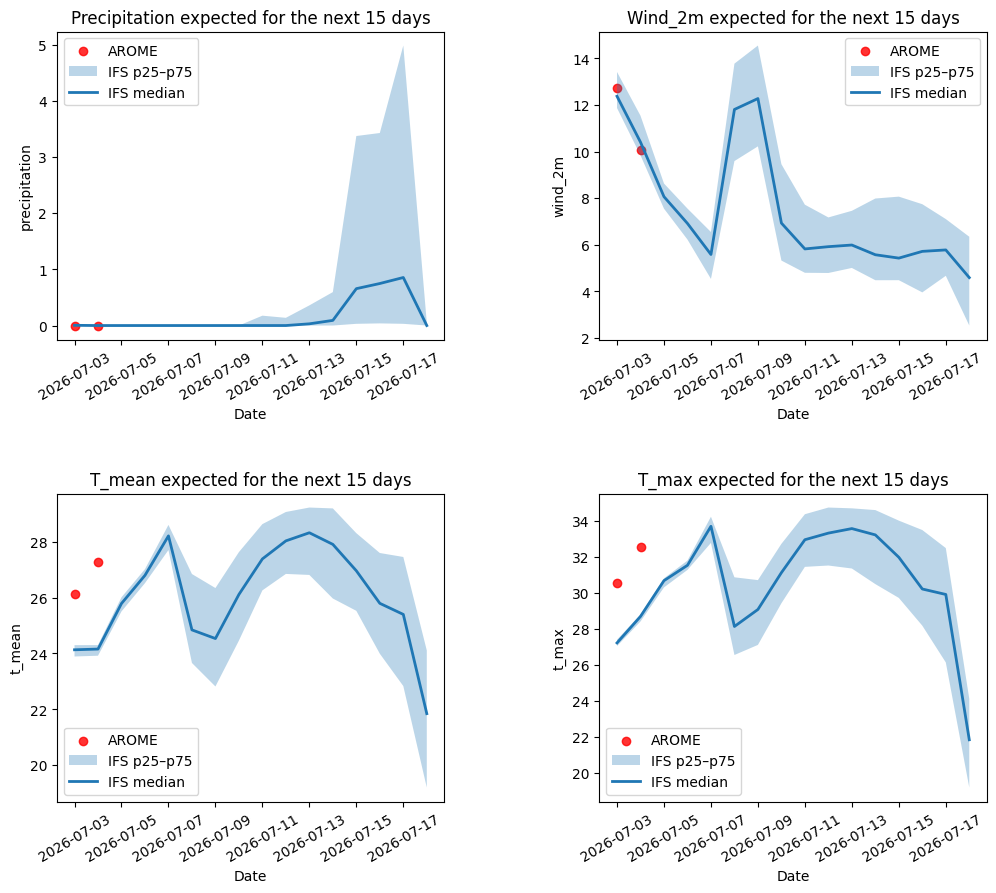

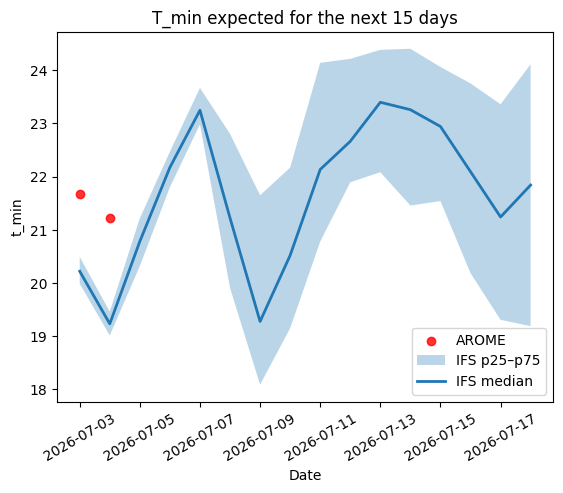

In [9]:
import matplotlib.pyplot as plt

def plot_covariate(arome_df, ifs_df, ax, covariate : str):
    # Make sure dates are sorted and datetime-like
    ifs_df["date"] = pd.to_datetime(ifs_df["date"])
    arome_df["date"] = pd.to_datetime(arome_df["date"])

    # Compute p25, median, p75 across IFS members for each date
    ifs_stats = (
        ifs_df.groupby("date")[covariate]
        .quantile([0.25, 0.5, 0.75])
        .unstack()
        .rename(columns={0.25: "p25", 0.5: "median", 0.75: "p75"})
        .reset_index()
        .sort_values("date")
    )

    

    # AROME scatter
    ax.scatter(arome_df["date"], arome_df[covariate], label="AROME", alpha=0.8, color="red")

    # IFS interquartile range
    ax.fill_between(
        ifs_stats["date"], ifs_stats["p25"], ifs_stats["p75"], alpha=0.3, label="IFS p25–p75"
    )

    # IFS median
    ax.plot(ifs_stats["date"], ifs_stats["median"], label="IFS median", linewidth=2)

    ax.set_xlabel("Date")
    ax.set_ylabel(covariate)
    ax.tick_params("x", rotation=30)
    ax.legend()
    ax.set_title(f"{covariate.capitalize()} expected for the next 15 days")

    return ax


# Plot Precip
fig,axes = plt.subplots(nrows=2,ncols=2, figsize=(12,10))
fig.subplots_adjust(
    wspace=0.4,  # horizontal space between columns
    hspace=0.5,  # vertical space between rows
)
plot_covariate(arome_df=arome_df, ifs_df=ifs_df, ax=axes[0,0], covariate="precipitation")

# Plot Wind
plot_covariate(arome_df=arome_df, ifs_df=ifs_df, ax=axes[0,1], covariate="wind_2m")


# Plot Temperature
plot_covariate(arome_df=arome_df, ifs_df=ifs_df, ax=axes[1,0], covariate="t_mean")

plot_covariate(arome_df=arome_df, ifs_df=ifs_df, ax=axes[1,1], covariate="t_max")


fig,ax = plt.subplots()
plot_covariate(arome_df=arome_df, ifs_df=ifs_df, ax=ax, covariate="t_min")


# TEST ARCHIVE

In [1]:
import logging
import os
from datetime import date
from pathlib import Path
from datetime import timedelta

# === EDIT THESE ===
REPO_ROOT = os.path.dirname(os.getcwd())  # adjust if needed
os.chdir(REPO_ROOT)

TODAY = date(2026, 7, 14)  # the date we treat as "today"
# TODAY = date.today()
SIMULATION_START = date(2026, 1, 1)  # start of the growing season simulation
LAST_IRRIGATION = None  # date of last irrigation, or None for rainfed
RUN_SEAS5 = False  # set True to include seasonal outlook (monthly run)
PLOT_SEAS5_PCA = True  # diagnostic ERA5-vs-SEAS5 PC1/PC2 figure
FETCH_SEAS5_HINDCASTS = False  # one-time: fetch 1993-2016 hindcasts for current init month
REFRESH_SEAS5 = False  # set True once if an old 2-variable SEAS5 cache exists
RUN_YIELD_OPTIMIZER = False  # requires RUN_SEAS5=True for a harvest-horizon objective
RUN_BRANCH_EQUIVALENCE_TEST = False  # compare private branching vs full AquaCrop on 3 members
RUN_HISTORICAL_OPTIMIZER = False  # retrospective fixed-date dose optimization

SHIFT = 0  # set to 1 if you want UTC+1

# Paths — all relative to REPO_ROOT
RAW_DIR = Path("data/raw")  # ERA5-Land, SEAS5, IFS ENS raw downloads
PROCESSED_DIR = Path("data/processed")  # daily aggregates, cached results
STATIC_DIR = Path("data/static")  # static ERA5-Land data (soil, land cover, etc.)


# Parcel and region configs (region still needed for static layers)
REGION_CONFIG = "configs/dordogne.yaml"
PARCEL_CONFIG = f"configs/parcels/billac_{TODAY.year}_no_irr.yaml"
PARCEL_CONFIG2 = f"configs/parcels/guide_{TODAY.year}_no_irr.yaml"


HISTORICAL_PARCEL_CONFIG = f"configs/parcels/billac_{TODAY.year}.yaml"
HISTORICAL_PARCEL_BIS_CONFIG = f"configs/parcels/guide_{TODAY.year}.yaml"

CROP_PARAMS_PATH = "configs/crop_parameters.yaml"
MODEL_PARAMS_PATH = "configs/model_parameters.yaml"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
    datefmt="%H:%M:%S",
)

print(f"Repo root: {REPO_ROOT}")
print(f"Today:     {TODAY}")
print(f"Raw dir:   {RAW_DIR}")
print(f"Processed: {PROCESSED_DIR}")

from irrigator.config import load_region_config, load_parcel_config

cfg = load_region_config(REGION_CONFIG)
parcel = load_parcel_config(PARCEL_CONFIG)


Repo root: /home/mbaldacchino/code/IrriGator
Today:     2026-07-14
Raw dir:   data/raw
Processed: data/processed


In [4]:
from datetime import date

from irrigator.ingestion.ifs_tigge_client import process_tigge_run
from irrigator.config import BBoxWGS84
box_test = BBoxWGS84(north=51.5, south=41.0, west=-6.0, east=10.0)

path = process_tigge_run(
    date(2026, 7, 15),
    run_hour=0,
    keep_raw=False,
)

print(path)


2026-09-09 17:14:01,225 INFO Request ID is 43350d4e-b741-4546-8ee0-519fa942dab2
2026-09-09 17:14:01,282 INFO status has been updated to accepted
2026-09-09 17:14:20,086 INFO status has been updated to running
2026-09-09 17:14:41,685 INFO status has been updated to successful


e73f87a5ca355838e0281488ffec3003.grib:   0%|          | 0.00/2.19M [00:00<?, ?B/s]

2026-09-09 17:14:46,207 INFO Request ID is d4764c2e-8da7-498c-a7af-c4c2a32d9882
2026-09-09 17:14:46,247 INFO status has been updated to accepted
2026-09-09 17:15:10,147 INFO status has been updated to running
2026-09-09 17:23:37,567 INFO status has been updated to successful


f1e1e76c73d33cead64b39be6dc55bbf.grib:   0%|          | 0.00/109M [00:00<?, ?B/s]

data/processed/ifs_tigge/ifs_daily_2026-07-15_00z.nc


In [ ]:
import xarray as xr

tigge = xr.open_dataset("data/processed/ifs_tigge/ifs_daily_2026-07-15_00z.nc")
ifs = xr.open_dataset(
    "/home/mbaldacchino/code/IrriGator/data/processed/ifs_ens/ifs_daily_2026-07-15_00z.nc"
)

import matplotlib.pyplot as plt

(tigge.isel(number=1, valid_time=0) - ifs.isel(number=0, valid_time=2)).t_mean.plot()


In [40]:
import numpy as np
variables = [
    "t_min",
    "t_max",
    "t_mean",
    "dewpoint",
    "pressure_kpa",
    "wind_speed_10m",
    "precip_mm",
    "rs_mj",
]

for var in variables:
    a = tigge[var].sel(
        latitude=parcel.lat,
        longitude=parcel.lon,
        method="nearest",
    )

    b = ifs[var].sel(
        latitude=parcel.lat,
        longitude=parcel.lon,
        method="nearest",
    )

    # same dates/members first
    a, b = xr.align(a, b, join="inner")

    diff = a - b

    print(
        var,
        "bias =",
        float(diff.mean()),
        "MAE =",
        float(abs(diff).mean()),
        "RMSE =",
        float(np.sqrt((diff**2).mean())),
    )


t_min bias = 0.11194406449794769 MAE = 0.11412085592746735 RMSE = 0.13051877604575954
t_max bias = 0.16874094307422638 MAE = 0.17523695528507233 RMSE = 0.1949741962214529
t_mean bias = 0.13354168832302094 MAE = 0.13415344059467316 RMSE = 0.14463961250607668
dewpoint bias = -0.16612520813941956 MAE = 0.17077280580997467 RMSE = 0.20293345957270997
pressure_kpa bias = 0.016137506812810898 MAE = 0.016137506812810898 RMSE = 0.016312941704002788
wind_speed_10m bias = 0.019382616505026817 MAE = 0.04403988644480705 RMSE = 0.058405239130153865
precip_mm bias = -0.0360097661614418 MAE = 0.2187948077917099 RMSE = 0.849022778988397
rs_mj bias = 2.1980836391448975 MAE = 2.1980836391448975 RMSE = 2.2196588938074244


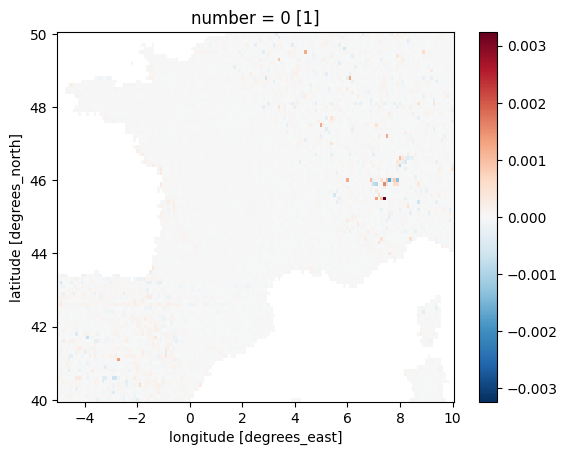

In [65]:
era5_rad = xr.open_dataset("/home/mbaldacchino/data/era5_radiation.nc")
fal = era5_rad.fal.resample({"valid_time": "1D"}).mean(skipna=True)
alpha_eff = 1 - era5_rad["ssr"] / era5_rad["ssrd"]
alpha_eff = alpha_eff.resample({"valid_time": "1D"}).mean(skipna=True)
(alpha_eff - fal).mean("valid_time").plot()

In [ ]:
from irrigator.atmospheric.albedo import process_era5_forecast_albedo

process_era5_forecast_albedo(year_range=(2007,2026))

22:56:00 [numexpr.utils] INFO: Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
22:56:00 [numexpr.utils] INFO: NumExpr defaulting to 16 threads.


PosixPath('data/processed/era5_albedo/albedo_era5_2007_2026.nc')

In [ ]:
from datetime import date

from irrigator.ingestion.ifs_tigge_client import run_tigge_pipeline
from irrigator.config import BBoxWGS84

def bbox_from_parcels(
    parcels,
    buffer_deg: float = 1.0,
) -> BBoxWGS84:
    """To add to code later !"""
    lats = [p.lat for p in parcels]
    lons = [p.lon for p in parcels]

    return BBoxWGS84(
        north=max(lats) + buffer_deg,
        south=min(lats) - buffer_deg,
        west=min(lons) - buffer_deg,
        east=max(lons) + buffer_deg,
    )

STUDY_BBOX = BBoxWGS84(
    north=46.5,
    south=44.5,
    west=-1.0,
    east=2.0,
)

paths = run_tigge_pipeline(
    start=date(2025, 5, 1),
    end=date(2025, 9, 30),
    run_hour=0,
    keep_raw=False,
    bbox=STUDY_BBOX,
)


In [41]:
from irrigator.ingestion.arome_historical_client import (
    archive_arome_previous_runs_year,
)

archive_arome_previous_runs_year(
    parcel,
    2025,
)


17:53:22 [irrigator.ingestion.arome_historical_client] INFO: Open-Meteo AROME previous runs: 2025-01-01 -> 2025-01-31, parcel=(45.3838, 0.4151), leads=(0, 1, 2)
17:53:23 [irrigator.ingestion.arome_historical_client] INFO: Open-Meteo AROME previous runs: 2025-02-01 -> 2025-03-03, parcel=(45.3838, 0.4151), leads=(0, 1, 2)
17:53:23 [irrigator.ingestion.arome_historical_client] INFO: Open-Meteo AROME previous runs: 2025-03-04 -> 2025-04-03, parcel=(45.3838, 0.4151), leads=(0, 1, 2)
17:53:24 [irrigator.ingestion.arome_historical_client] INFO: Open-Meteo AROME previous runs: 2025-04-04 -> 2025-05-04, parcel=(45.3838, 0.4151), leads=(0, 1, 2)
17:53:24 [irrigator.ingestion.arome_historical_client] INFO: Open-Meteo AROME previous runs: 2025-05-05 -> 2025-06-04, parcel=(45.3838, 0.4151), leads=(0, 1, 2)
17:53:24 [irrigator.ingestion.arome_historical_client] INFO: Open-Meteo AROME previous runs: 2025-06-05 -> 2025-07-05, parcel=(45.3838, 0.4151), leads=(0, 1, 2)
17:53:25 [irrigator.ingestion.arom

PosixPath('data/processed/arome/historical/billac_001/arome_previous_runs_meteofrance_arome_france_2025.nc')

In [ ]:
from datetime import date

from irrigator.forecasts.historical import get_historical_forecast

forecast = get_historical_forecast(
    issue_date=date(2025, 7, 15),
    parcel=parcel,
    terrain=terrain,
    forecast_days=15,
)

arome_forcing = forecast.arome_forcing
member_forcings = forecast.ifs_member_forcings

print(forecast.arome_source)
print(forecast.ifs_source)

print(arome_forcing.to_dataframe())

print(
    len(member_forcings),
    member_forcings[0].dates[0],
    member_forcings[0].dates[-1],
)
